## Installing and importing the necessary libraries

In [325]:
# Installing the libraries with the specified version
!pip install --no-deps --force-reinstall tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 --no-deps --force-reinstall -q --user --no-warn-script-location

ERROR: Could not find a version that satisfies the requirement tensorflow==2.18.0 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0, 2.22.0rc0)
ERROR: No matching distribution found for tensorflow==2.18.0


In [326]:
import pandas as pd  # Library for data manipulation and analysis.
import numpy as np   # Fundamental package for scientific computing.
import matplotlib.pyplot as plt  # Plotting library for creating visualizations.
import seaborn as sns #For advanced visualizations.

from sklearn.model_selection import train_test_split  # Function for splitting datasets for training and testing.

import time  # Module for time-related operations.

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense   # for creating fully connected neural network layers.

In [327]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it might affect the overall performance
tf.config.experimental.enable_op_determinism()

## Data Overview

In [328]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [329]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


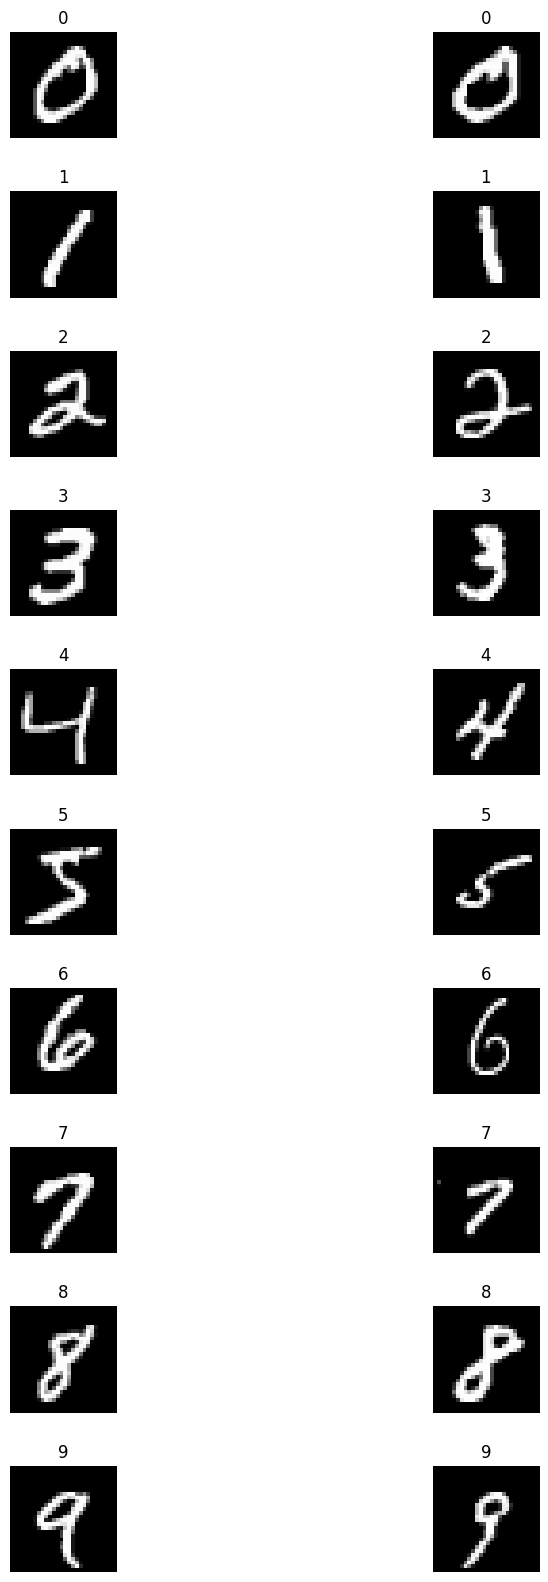

In [330]:
f, axarr = plt.subplots(10, 2, figsize=(10, 20))
for i in range(10):
    images = x_train[y_train == i]
    axarr[i, 0].imshow(images[0], cmap="gray")
    axarr[i, 1].imshow(images[1], cmap="gray")
    axarr[i, 0].axis("off")
    axarr[i, 1].axis("off")
    axarr[i, 0].set_title(str(i))
    axarr[i, 1].set_title(str(i))

plt.subplots_adjust(hspace=0.5)
plt.show()

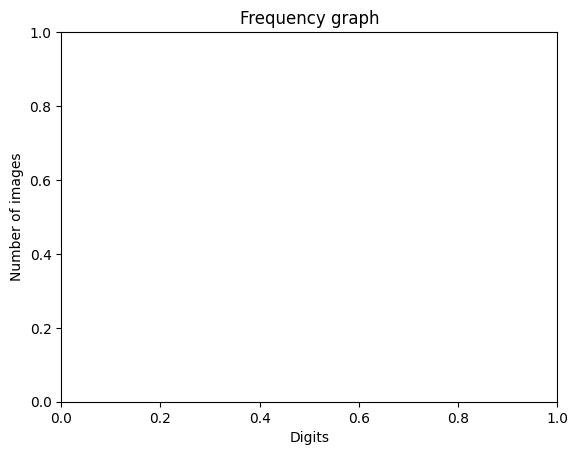

In [331]:
(pd.Series(y_train).value_counts())[[0, 1, 2, 3, 4, 5, 6, 7, 9, 8]]
plt.title("Frequency graph")
plt.xlabel("Digits")
plt.ylabel("Number of images")
plt.show()

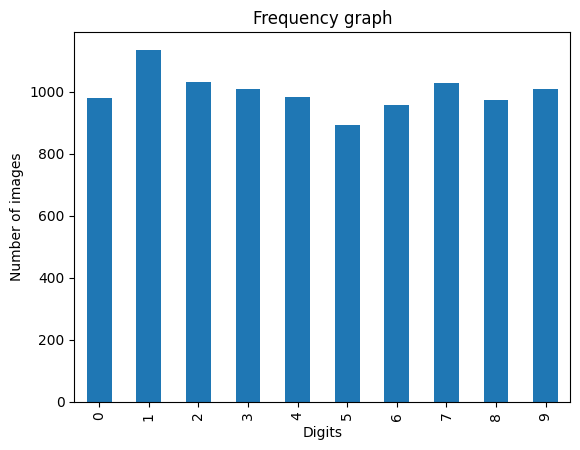

In [332]:
(pd.Series(y_test).value_counts())[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]].plot.bar()
plt.title("Frequency graph")
plt.xlabel("Digits")
plt.ylabel("Number of images")
plt.show()

In [333]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=1-(5/6), random_state=42,stratify=y_train)

In [334]:
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

(50000, 28, 28)
(50000,)
(10000, 28, 28)
(10000,)


In [335]:
print(x_train.max(),x_test.max(),x_val.max())
print(x_train.min(),x_test.min(),x_val.min())

255 255 255
0 0 0


In [336]:
x_train, x_val, x_test = x_train.astype("float32")/(255), x_val.astype("float32")/(255), x_test.astype("float32")/(255)

In [337]:
print(x_train.max(),x_test.max(),x_val.max())
print(x_train.min(),x_test.min(),x_val.min())

1.0 1.0 1.0
0.0 0.0 0.0


In [338]:
x_train = x_train.reshape(x_train.shape[0],-1)
x_val = x_val.reshape(x_val.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)
print(x_train.shape[0], "train samples")
print(x_val.shape[0], "validation samples")
print(x_test.shape[0], "test samples")

50000 train samples
10000 validation samples
10000 test samples


In [339]:
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_train

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [340]:
def plot(history, name):
    fig, ax = plt.subplots()
    plt.plot(history.history[name])
    plt.plot(history.history["val_" + name])

    plt.title("Model " + name.capitalize())
    plt.ylabel(name.capitalize())
    plt.xlabel("Epoch")
    fig.legend(["Train", "Validation"], loc="outside right upper")

In [341]:
columns = [
    "# hidden layers",
    "# neurons - hidden layer",
    "activation function - hidden layer",
    "# epochs",
    "batch size",
    "train loss",
    "validation loss",
    "train accuracy",
    "validation accuracy",
    "time (secs)",
]

results = pd.DataFrame(columns=columns)

In [342]:
tf.keras.backend.clear_session()


In [343]:
model = Sequential()
model.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[0]))
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [344]:
model.summary()
batch_size = x_train.shape[0]
epochs = 10
start = time.time()
history = model.fit(
    x_train, y_train,
    validation_data=(x_val,y_val),
    batch_size=batch_size,
    epochs=epochs)
end = time.time()
print("Time taken in seconds ",end-start)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │       500,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,010 (1.91 MB)

 Trainable params: 500,010 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense' is incompatible with the layer: expected axis -1 of input shape to have value 50000, but received input with shape (50000, 784)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(50000, 784), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
plot(history,'loss')

In [345]:
results.loc[0] = [0,[10,50000],history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

NameError: name 'history' is not defined

In [ ]:
results

In [ ]:
tf.keras.backend.clear_session()
model = Sequential()
model.add(Dense(128,'relu',input_dim = x_train.shape[0]))
model.add(Dense(64,'tanh',input_dim = x_train.shape[0]))
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])
model.summary()
batch_size = 32
epochs = 50
start = time.time()
history = model.fit (
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=batch_size,
    epochs = epochs
)
end = time.time()
print("Time taken in seconds ", end-start)

In [ ]:
results.loc[10] = [2,[128,64],['relu','tanh'],history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]